<a href="https://colab.research.google.com/github/BenjaminJones-lccc/Week-5-learning/blob/main/Week_5_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Linear Regression**

# **Introduction to Linear Regression**

Linear regression is the most commonly used
statistical method of predictive analysis.

It uses linear relationships between a dependent
variable (target) and one or more independent
variables (predictors) to predict the future of the
target.

The prediction is based on the assumption that the
relationship between the target and the predictors
is dependent or causal.

## **Implement Linear Regression**

The basic idea is that if we can fit a linear regression model to observed data, we can then use the model to predict any future values.

For example, let’s assume that we have found from historical data that the price (P) of a house is linearly dependent upon its size (S) — in fact, we found that a house’s price is exactly 90 times its size. The equation will look like this:


P = 90*S


With this model, we can then predict the cost of any house. If we have a house that is 1,500 square feet, we can calculate its price to be:


P = 90*1500 = $135,000

## **Variables in Linear Regression**

There are two kinds of variables in a linear regression model:


- The input or predictor variable is the variable(s) that help predict the value of the output variable. It is commonly referred to as X.
- The output variable is the variable that we want to predict. It is commonly referred to as Y.


To estimate Y using linear regression, we assume the equation:


Yₑ = α + β X


where Yₑ is the estimated or predicted value of Y based on our linear equation.


Our goal is to find statistically significant values of the parameters α and β that minimise the difference between Y and Yₑ.


If we are able to determine the optimum values of these two parameters, then we will have the line of best fit that we can use to predict the values of Y, given the value of X.
So, how do we estimate α and β? We can use a method called **ordinary least squares.**

## **Ordinary Least Squares**

The objective of the least squares method is to find values of α and β that minimise the sum of the squared difference between Y and Yₑ.

![Ordinal%20Formula.gif](attachment:Ordinal%20Formula.gif)



where X̄ is the mean of X values and Ȳ is the mean of Y values.


If you are familiar with statistics, you may recognise β as simply Cov(X, Y) / Var(X).

# **Import Libraries**

In [1]:
import pandas as pd #Pandas for managing datasets. pd is used as an alias for pandas
import numpy as np
from matplotlib import pyplot as plt #matplotlib.pyplot: for plotting

# **Generate Dataset**

In [2]:
# Generate 'random' data
np.random.seed(0)
X = 2.5 * np.random.randn(100) + 1.5   # Array of 100 values with mean = 1.5, stddev = 2.5
res = 0.5 * np.random.randn(100)       # Generate 100 residual terms
y = 2 + 0.3 * X + res                  # Actual values of Y

# Create pandas dataframe to store our X and y values
df = pd.DataFrame(
    {'X': X,
     'y': y}
)

# Show the first five rows of our dataframe
df.head()

,X,y
0,5.910131,4.714615
1,2.500393,2.076238
2,3.946845,2.548811
3,7.102233,4.615368
4,6.168895,3.264107


# **Calculating Mean and Covariance**



To estimate y using the OLS method, we need to calculate xmean and ymean, the covariance of X and y (xycov), and the variance of X (xvar) before we can determine the values for alpha and beta.


In [3]:
# Calculate the mean of X and y
xmean = np.mean(X)
ymean = np.mean(y)

# Calculate the terms needed for the numator and denominator of beta
df['xycov'] = (df['X'] - xmean) * (df['y'] - ymean)
df['xvar'] = (df['X'] - xmean)**2

# Calculate beta and alpha
beta = df['xycov'].sum() / df['xvar'].sum()
alpha = ymean - (beta * xmean)
print(f'alpha = {alpha}')
print(f'beta = {beta}')

alpha = 2.0031670124623426
beta = 0.3229396867092763


**Great, we now have an estimate for alpha and beta**

Our model can be written as

**Yₑ = 2.003 + 0.323 X,**

and we can make predictions:

In [4]:
ypred = alpha + beta * X
ypred

array([3.91178282, 2.81064315, 3.27775989, 4.29675991, 3.99534802,
       1.69857201, 3.25462968, 2.36537842, 2.40424288, 2.81907292,
       2.60387001, 3.66168312, 3.10199975, 2.58581077, 2.84592918,
       2.75696825, 3.69382011, 2.32194218, 2.74033151, 1.79802302,
       0.42642221, 3.015275  , 3.18547843, 1.88839019, 4.32006116,
       1.31339555, 2.52451965, 2.33645381, 3.72506464, 3.67386219,
       2.61267323, 2.79288576, 1.77082341, 0.88838207, 2.20668994,
       2.61380476, 3.48085076, 3.45831697, 2.17486854, 2.24351265,
       1.64102813, 1.34112617, 1.11002064, 4.06253353, 2.07610925,
       2.1338976 , 1.47613319, 3.11528277, 1.18459738, 2.31582084,
       1.76462232, 2.79994197, 2.07517841, 1.53439407, 2.46482364,
       2.83338994, 2.54127917, 2.73177699, 1.9754571 , 2.19471775,
       1.94466613, 2.19729158, 1.83108353, 1.09386364, 2.6308214 ,
       2.16319902, 1.17143718, 2.86120343, 1.75506992, 2.52951462,
       3.07620724, 2.59171079, 3.40747079, 1.49064088, 2.81240

# **Prediction**

Let’s plot our prediction ypred against the actual values of y, to get a better visual understanding of our model.

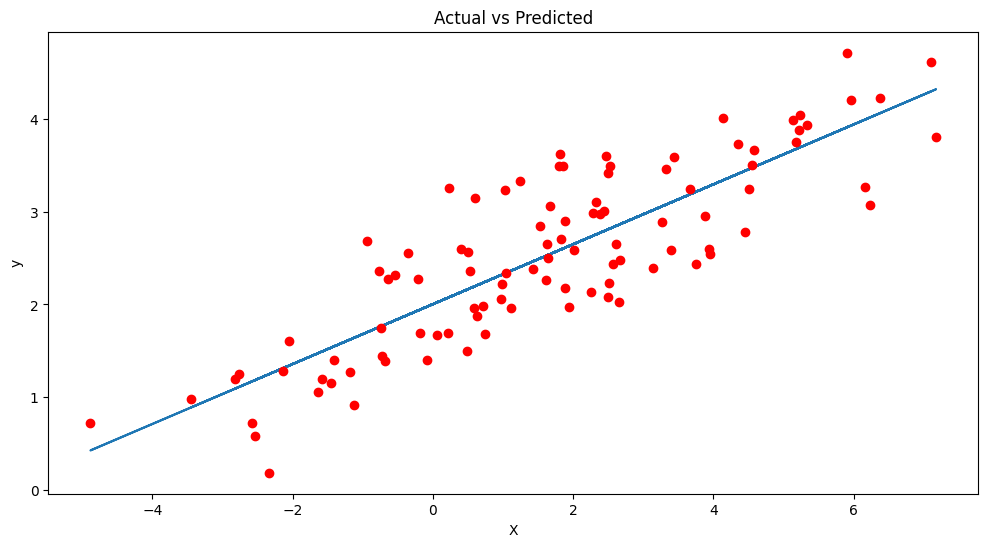

In [5]:

# Plot regression against actual data
plt.figure(figsize=(12, 6))
plt.plot(X, ypred)     # regression line
plt.plot(X, y, 'ro')   # scatter plot showing actual data
plt.title('Actual vs Predicted')
plt.xlabel('X')
plt.ylabel('y')

plt.show()